## Read data and merge in one dataset

In [3]:
import pandas as pd
import json

df_train = pd.read_csv('data/codex/train.txt', sep='\t', header=None, names=['Head','Relation','Tail'])
df_test = pd.read_csv('data/codex/test.txt', sep='\t', header=None, names=['Head','Relation','Tail'])
df_valid = pd.read_csv('data/codex/valid.txt', sep='\t', header=None, names=['Head','Relation','Tail'])

with open('data/codex/entities.json', 'r') as file:
    entities = json.load(file)

with open('data/codex/relations.json', 'r') as file:
    relations = json.load(file)

def id2name_df(id_df:pd.DataFrame, entities_dict:dict, relations_dict:dict)-> pd.DataFrame:
    name_dict = {}
    for id, row in id_df.iterrows():
        # get id
        head_id = row['Head']
        relation_id = row['Relation']
        tail_id = row['Tail']
        # get label out of id
        head = entities_dict[head_id]['label']
        relation = relations_dict[relation_id]['label']
        tail = entities_dict[tail_id]['label']
        name_dict[id] = [head,relation,tail]
    name_df = pd.DataFrame.from_dict(name_dict,orient='index',columns=['Head','Relation','Tail'])
    return name_df

df_train_name = id2name_df(df_train, entities, relations)
df_test_name = id2name_df(df_test, entities, relations)
df_valid_name = id2name_df(df_valid, entities, relations)

df_name = pd.concat([df_train_name, df_test_name, df_valid_name]).reset_index(drop=True)

## Generate candidates and embedding


In [1]:
from cand_gen.embedding import train_model
from cand_gen import triple_gen
import cand_gen.embedding
import importlib
from cand_gen.embedding.get_emb_transe import get_list_dist

/opt/homebrew/Caskroom/miniconda/base/envs/kg-emb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Generate embedding

In [ ]:
df_name_sample = df_name.sample(int(0.8*len(df_name)))
train_df = train_model.create_dataset(
    df_name_sample)
test_df = train_model.create_dataset(
    df_name_sample.sample(n=50))


embedding_dim = 5
model_kwargs = {"embedding_dim": embedding_dim}

model_dict = {}
#model_list = ['TransE','TransH','TransF','TransR','TransD']
model_list = ['TransE']
for model_name in model_list:
    experiment_name = model_name+f"_dim{embedding_dim}"
    model = train_model.create_pipeline(train_df, test_df,
                        model_name, model_kwargs, experiment_name)
    model_dict[model_name] = model

In [5]:
def filter_candidates(candidates_df:pd.DataFrame, threshold:float) -> pd.DataFrame:
    candidates_sample_df = candidates_df[candidates_df['distance']<threshold]
    candidates_sample_df = candidates_sample_df[['Head','Relation','Tail']]
    return candidates_sample_df

def compute_missing_df(original_df:pd.DataFrame, sample_df:pd.DataFrame) -> pd.DataFrame:
    df_missing = original_df[~df_name.apply(tuple, axis=1).isin(sample_df.apply(tuple, axis=1))]
    return df_missing

def compute_coverage(filtred_df :pd.DataFrame, df_missing:pd.DataFrame) -> float:
    df_coverage = filtred_df[filtred_df.apply(tuple, axis=1).isin(df_missing.apply(tuple, axis=1))]
    coverage = len(df_coverage) / len(df_missing)
    return coverage

### Generate candidates and filter the candidates using embedding

In [6]:
transe_score_dict = {}
candidates_df = triple_gen.generate_all_candidates(df_name_sample)
model = model_dict['TransE']
list_dist = get_list_dist(candidates_df, model.model, train_df)
candidates_df['distance'] = list_dist
proportion_dict = {}

mean_dist = candidates_df['distance'].mean()
std_dist = candidates_df['distance'].std()

threshold_list = [mean_dist- std_dist, mean_dist-0.5*std_dist,mean_dist,
                mean_dist+0.5*std_dist,mean_dist + std_dist]
for threshold in threshold_list:
    filtred_df = filter_candidates(candidates_df, threshold)
    df_missing = compute_missing_df(df_name, df_name_sample)
    coverage = compute_coverage(filtred_df, df_missing)
    reduction_ratio = len(filtred_df)/len(candidates_df)
    new_score = coverage/reduction_ratio
    transe_score_dict[threshold] = new_score, reduction_ratio, coverage
    proportion_dict[threshold] = reduction_ratio

In [11]:
for key in transe_score_dict.keys():
    score = format(transe_score_dict[key][0],'.2f')
    reduction_ratio = format(1- transe_score_dict[key][1],'.2f')
    coverage = format(transe_score_dict[key][2],'.2f')
    rr_cov = format((1- transe_score_dict[key][1])*transe_score_dict[key][2],'.2f')
    print(f'Treshold:{format(key,'.2f')}\t score:{score}\t RR:{reduction_ratio}\t Coverage:{coverage}\t RR*Cov:{rr_cov}')

Treshold:1.28	 score:1.96	 RR:0.83	 Coverage:0.32	 RR*Cov:0.27
Treshold:1.68	 score:1.39	 RR:0.68	 Coverage:0.45	 RR*Cov:0.30
Treshold:2.07	 score:1.29	 RR:0.48	 Coverage:0.66	 RR*Cov:0.32
Treshold:2.47	 score:1.21	 RR:0.30	 Coverage:0.85	 RR*Cov:0.25
Treshold:2.87	 score:1.13	 RR:0.16	 Coverage:0.95	 RR*Cov:0.15


In [16]:
rr_cov_list = [(1- transe_score_dict[key][1])*transe_score_dict[key][2] for key in transe_score_dict]
index_threshold = rr_cov_list.index(max(rr_cov_list))
threshold = threshold_list[index_threshold]
filtred_df = filter_candidates(candidates_df, threshold)

## Label true and false missing candidates

In [22]:
missing_df = compute_missing_df(df_name, df_name_sample)
cand_df = filtred_df
true_cand_df = cand_df[cand_df.apply(tuple, axis=1).isin(missing_df.apply(tuple, axis=1))]
false_cand_df = cand_df[~cand_df.apply(tuple, axis=1).isin(missing_df.apply(tuple, axis=1))]
true_cand_df['Missing'] = 1
false_cand_df['Missing'] = 0

/var/folders/_3/wtwzgv1d3rlfz233qkf36kg00000gp/T/ipykernel_44762/2986374826.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  true_cand_df['Missing'] = 1
/var/folders/_3/wtwzgv1d3rlfz233qkf36kg00000gp/T/ipykernel_44762/2986374826.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false_cand_df['Missing'] = 0


In [24]:
df_size = 500
test_df = pd.concat([true_cand_df.sample(int(df_size/2)), false_cand_df.sample(int(df_size/2))])

## Evaluate using LLM

In [44]:
import llm_eval.eval
from llm_eval.eval import eval_df, eval_df_context

def clean_score(list_score, thresh) -> list[float]:
    list_score = [item.rstrip('.') if item.endswith('.') else item for item in list_score]
    #list_score = [item for item in list_score if item and item.strip()]
    list_score = [0 if item == '' else item for item in list_score]
    score_bin = [1 if float(item) > thresh else 0 for item in list_score]
    return score_bin

In [27]:
score_cand = eval_df(test_df, 500)
score_cand_cont = eval_df_context(test_df, 500)

100/500
200/500
300/500
400/500
500/500
Finished

100/500
200/500
300/500
400/500
500/500
Finished



In [45]:
score_cand_clean = clean_score(score_cand, 0.6)
score_cand_cont_clean = clean_score(score_cand_cont, 0.6)

In [47]:
test_df['Pred'] = score_cand_clean
test_df['Cont pred'] = score_cand_cont_clean

In [48]:
test_df

,Head,Relation,Tail,Missing,Pred,Cont pred
312685,United Arab Emirates,member of,Group on Earth Observations,1,1,1
309197,Brazil,diplomatic relation,Uruguay,1,1,1
960574,Claudio Magris,occupation,translator,1,1,1
349683,Ivory Coast,diplomatic relation,Germany,1,1,1
302287,New Zealand,member of,UNESCO,1,1,1
...,...,...,...,...,...,...
1026427,Yoshiki,influenced by,Kanye West,0,1,1
1118477,Serge Gainsbourg,influenced by,Mark Twain,0,1,1
1003386,Sean Combs,diplomatic relation,Paraguay,0,1,1
1238207,Joss Stone,influenced by,Plato,0,0,1


## Plot evaluation


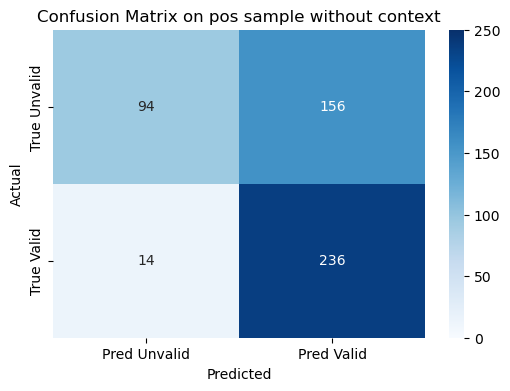

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

ground_truth = test_df['Missing']
prediction = test_df['Pred']
# Generate the confusion matrix
cm = confusion_matrix(ground_truth, prediction)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Unvalid', 'Pred Valid'], yticklabels=['True Unvalid', 'True Valid'],  vmin=0, vmax=250)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on pos sample without context')
plt.show()

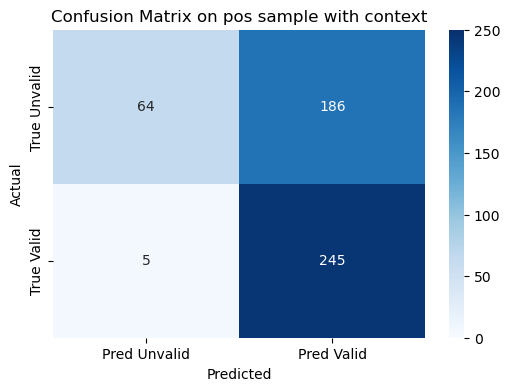

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

ground_truth = test_df['Missing']
prediction = test_df['Cont pred']
# Generate the confusion matrix
cm = confusion_matrix(ground_truth, prediction)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Unvalid', 'Pred Valid'], yticklabels=['True Unvalid', 'True Valid'],  vmin=0, vmax=250)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on pos sample with context')
plt.show()